In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from google.colab import files
drive.mount('/content/drive')
uploaded=files.upload()
print(uploaded)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving Zingaro_Company.csv to Zingaro_Company.csv
Saving Dental Hardness data.xlsx to Dental Hardness data.xlsx
{'Zingaro_Company.csv': b'Unpolished ,Treated and Polished\r\n164.4817129,133.2093928\r\n154.3070452,138.4827707\r\n129.8610478,159.6652012\r\n159.0961836,145.6635282\r\n135.2567483,136.7892272\r\n161.8201202,167.086582\r\n149.4550537,152.6996408\r\n135.7143169,138.6487657\r\n102.0045188,163.3844269\r\n89.482158,132.1417257\r\n95.34903009,145.8285257\r\n104.4214033,162.0816128\r\n140.8893522,153.798449\r\n147.3666473,159.0120051\r\n48.40683839,168.3462233\r\n68.25154209,132.6829555\r\n126.1698324,151.2738748\r\n130.4361532,130.9558037\r\n120.8943152,141.3442879\r\n107.2753413,171.1146621\r\n64.57581982,139.7076719\r\n136.6500503,125.8485996\r\n94.63178559,152.3545271\r\n154.6701824,155.1468488\r\n75.28981154,145.2061887\r\n149.0171371,168.6528203\r\n162.3573614,131.9871467\r\n113.6495183,148.595124\r\n120.4372985,138.0538286\r\n100.8909747,134.7560427\r\n98.86570856,142.15678

Problem 1.
A physiotherapist with a male football team is interested in studying the relationship between foot injuries and the positions at which the players play from the data collected.

In [ ]:
import pandas as pd

# Create the dataset
data = {
    "Position": ["Striker", "Forward", "Attacking Midfielder", "Winger", "Total"],
    "Players Injured": [45, 56, 24, 20, 145],
    "Players Not Injured": [32, 38, 11, 9, 90],
    "Total": [77, 94, 35, 29, 235]
}

# Make a DataFrame
df = pd.DataFrame(data)

# Display
print(df)

# Optional: Save to Excel/CSV
df.to_excel("injury_data.xlsx", index=False)
df.to_csv("injury_data.csv", index=False)


               Position  Players Injured  Players Not Injured  Total
0               Striker               45                   32     77
1               Forward               56                   38     94
2  Attacking Midfielder               24                   11     35
3                Winger               20                    9     29
4                 Total              145                   90    235


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Cleaning ---
# 1. Check for null values
print("Missing values per column:\n", df.isnull().sum())

# 2. Drop duplicates if any
df = df.drop_duplicates()

# 3. Handle missing values (if needed, here filling with mean)
df = df.fillna(df.mean(numeric_only=True))

# --- Data Summary ---
print("\nBasic Statistics:\n", df.describe())

Missing values per column:
 Position       0
Injured        0
Not Injured    0
Total          0
dtype: int64

Basic Statistics:
          Injured  Not Injured      Total
count   4.000000     4.000000   4.000000
mean   36.250000    22.500000  58.750000
std    17.134274    14.662878  31.752953
min    20.000000     9.000000  29.000000
25%    23.000000    10.500000  33.500000
50%    34.500000    21.500000  56.000000
75%    47.750000    33.500000  81.250000
max    56.000000    38.000000  94.000000


Criteria1.1 What is the probability that a randomly chosen player would suffer an injury?

In [ ]:
import pandas as pd

# Create dataset
data = {
    "Position": ["Striker", "Forward", "Attacking Midfielder", "Winger"],
    "Injured": [45, 56, 24, 20],
    "Not Injured": [32, 38, 11, 9]
}
df = pd.DataFrame(data)
df["Total"] = df["Injured"] + df["Not Injured"]

# Calculate probability
total_injured = df["Injured"].sum()
total_players = df["Total"].sum()

prob_injury = total_injured / total_players

print(f"Probability that a randomly chosen player would suffer an injury: {prob_injury:.3f} ({prob_injury*100:.1f}%)")


Probability that a randomly chosen player would suffer an injury: 0.617 (61.7%)


Criteria1.2 What is the probability that a player is a forward or a winger?

In [ ]:
import pandas as pd

# Create dataset
data = {
    "Position": ["Striker", "Forward", "Attacking Midfielder", "Winger"],
    "Injured": [45, 56, 24, 20],
    "Not Injured": [32, 38, 11, 9]
}
df = pd.DataFrame(data)
df["Total"] = df["Injured"] + df["Not Injured"]

# Calculate probability (Forward or Winger)
forward_winger_total = df.loc[df["Position"].isin(["Forward", "Winger"]), "Total"].sum()
total_players = df["Total"].sum()

prob_forward_winger = forward_winger_total / total_players

print(f"Probability that a player is a Forward or Winger: {prob_forward_winger:.3f} ({prob_forward_winger*100:.1f}%)")


Probability that a player is a Forward or Winger: 0.523 (52.3%)


Criteria1.3 What is the probability that a randomly chosen player plays in a striker position and has a foot injury?  

In [ ]:
import pandas as pd

# Create dataset
data = {
    "Position": ["Striker", "Forward", "Attacking Midfielder", "Winger"],
    "Injured": [45, 56, 24, 20],
    "Not Injured": [32, 38, 11, 9]
}
df = pd.DataFrame(data)
df["Total"] = df["Injured"] + df["Not Injured"]

# Calculate probability (Striker AND Injured)
striker_injured = df.loc[df["Position"]=="Striker", "Injured"].values[0]
total_players = df["Total"].sum()

prob_striker_injured = striker_injured / total_players

print(f"Probability that a randomly chosen player is a Striker and Injured: {prob_striker_injured:.3f} ({prob_striker_injured*100:.1f}%)")


Probability that a randomly chosen player is a Striker and Injured: 0.191 (19.1%)


Criteria1.4 What is the probability that a randomly chosen injured player is a striker?  

In [ ]:
import pandas as pd

# Create dataset
data = {
    "Position": ["Striker", "Forward", "Attacking Midfielder", "Winger"],
    "Injured": [45, 56, 24, 20],
    "Not Injured": [32, 38, 11, 9]
}
df = pd.DataFrame(data)
df["Total"] = df["Injured"] + df["Not Injured"]

# Calculate probability (Striker | Injured)
striker_injured = df.loc[df["Position"]=="Striker", "Injured"].values[0]
total_injured = df["Injured"].sum()

prob_striker_given_injured = striker_injured / total_injured

print(f"Probability that a randomly chosen injured player is a Striker: {prob_striker_given_injured:.3f} ({prob_striker_given_injured*100:.1f}%)")


Probability that a randomly chosen injured player is a Striker: 0.310 (31.0%)


Chi-Square Test of Independence

In [ ]:
import pandas as pd
import scipy.stats as stats

# Data
data = {
    "Position": ["Striker", "Forward", "Attacking Midfielder", "Winger"],
    "Injured": [45, 56, 24, 20],
    "Not Injured": [32, 38, 11, 9]
}

df = pd.DataFrame(data)

# Total players
total_players = df["Injured"].sum() + df["Not Injured"].sum()

# 1.1 P(Injury)
p_injury = df["Injured"].sum() / total_players

# 1.2 P(Forward or Winger)
p_fw = (df.loc[df["Position"].isin(["Forward","Winger"]), ["Injured","Not Injured"]].sum().sum()) / total_players

# 1.3 P(Striker and Injured)
p_striker_inj = df.loc[df["Position"]=="Striker", "Injured"].values[0] / total_players

# 1.4 P(Striker | Injured)
p_striker_given_inj = df.loc[df["Position"]=="Striker", "Injured"].values[0] / df["Injured"].sum()

print("1.1 P(Injury):", round(p_injury,3))
print("1.2 P(Forward or Winger):", round(p_fw,3))
print("1.3 P(Striker and Injured):", round(p_striker_inj,3))
print("1.4 P(Striker | Injured):", round(p_striker_given_inj,3))

# ---- Inferential Test: Chi-square ----
obs = df[["Injured","Not Injured"]].values
chi2, p, dof, expected = stats.chi2_contingency(obs)

print("\nChi-square test results:")
print(f"Chi² = {chi2:.3f}, df = {dof}, p-value = {p:.3f}")


1.1 P(Injury): 0.617
1.2 P(Forward or Winger): 0.523
1.3 P(Striker and Injured): 0.191
1.4 P(Striker | Injured): 0.31

Chi-square test results:
Chi² = 1.873, df = 3, p-value = 0.599


The breaking strength of gunny bags used for packaging cement is normally distributed with a mean of 5 kg per sq. centimeter and a standard deviation of 1.5 kg per sq. centimeter. The quality team of the cement company wants to know the following about the packaging material to better understand wastage or pilferage within the supply chain; Answer the questions below based on the given information; (Provide an appropriate visual representation of your answers, without which marks will be deducted)

2.1 What proportion of the gunny bags have a breaking strength of less than 3.17 kg per sq cm?

Proportion with strength < 3.17 = 0.111 (11.1%)


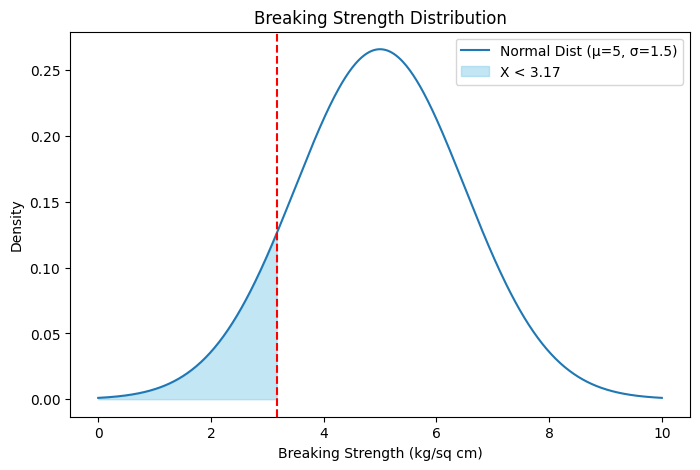

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
mu = 5
sigma = 1.5
x_value = 3.17

# Probability
p_less = norm.cdf(x_value, mu, sigma)
print(f"Proportion with strength < 3.17 = {p_less:.3f} ({p_less*100:.1f}%)")

# Visualization
x = np.linspace(0,10,500)
y = norm.pdf(x, mu, sigma)

plt.figure(figsize=(8,5))
plt.plot(x, y, label="Normal Dist (μ=5, σ=1.5)")
plt.fill_between(x, y, where=(x<=x_value), color="skyblue", alpha=0.5, label=f"X < {x_value}")
plt.axvline(x_value, color="red", linestyle="--")
plt.title("Breaking Strength Distribution")
plt.xlabel("Breaking Strength (kg/sq cm)")
plt.ylabel("Density")
plt.legend()
plt.show()


2.2 What proportion of the gunny bags have a breaking strength of at least 3.6 kg per sq cm.?

Proportion of bags with breaking strength >= 3.6: 0.8247 (82.47%)


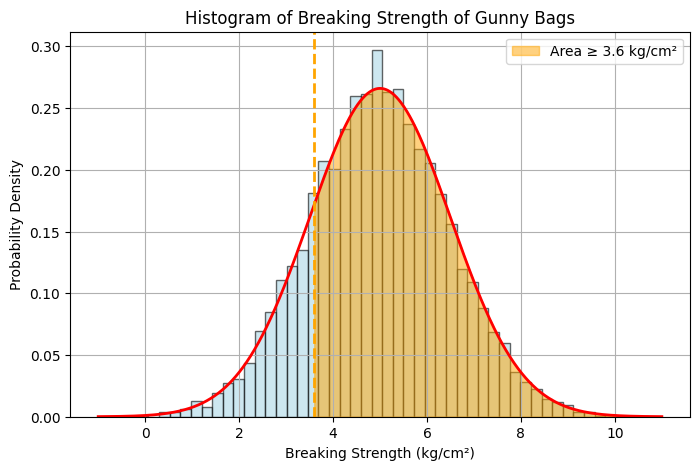

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Given data
mu = 5
sigma = 1.5
X = 3.6

# Step 1: Calculate probability
prob_less = norm.cdf(X, mu, sigma)
prob_at_least = 1 - prob_less
print(f"Proportion of bags with breaking strength >= {X}: {prob_at_least:.4f} ({prob_at_least*100:.2f}%)")

# Step 2: Generate data for histogram
np.random.seed(0)  # for reproducibility
samples = np.random.normal(mu, sigma, 10000)

# Step 3: Plot histogram
plt.figure(figsize=(8,5))
plt.hist(samples, bins=50, density=True, alpha=0.6, color='lightblue', edgecolor='black')

# Overlay normal distribution curve
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2)

# Highlight area X >= 3.6
x_fill = np.linspace(X, mu + 4*sigma, 1000)
plt.fill_between(x_fill, norm.pdf(x_fill, mu, sigma), 0, color='orange', alpha=0.5, label=f'Area ≥ {X} kg/cm²')

plt.axvline(X, color='orange', linestyle='--', lw=2)
plt.title('Histogram of Breaking Strength of Gunny Bags')
plt.xlabel('Breaking Strength (kg/cm²)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()


2.3 What proportion of the gunny bags have a breaking strength between 5 and 5.5 kg per sq cm.?

Proportion of bags with breaking strength between 5 and 5.5: 0.1306 (13.06%)


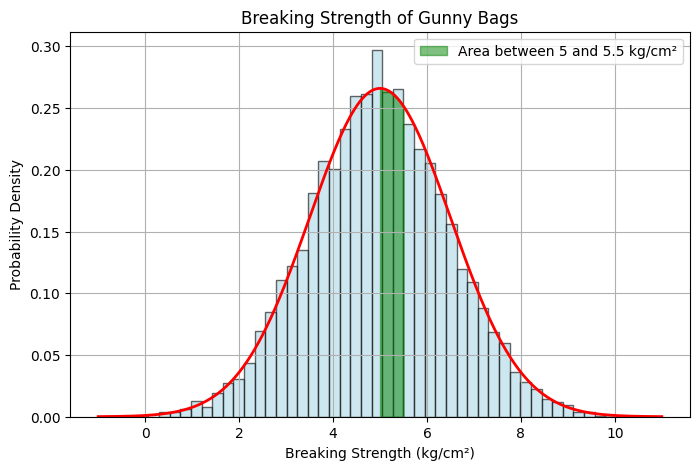

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Given data
mu = 5
sigma = 1.5
X1 = 5
X2 = 5.5

# Step 1: Calculate probability
prob_between = norm.cdf(X2, mu, sigma) - norm.cdf(X1, mu, sigma)
print(f"Proportion of bags with breaking strength between {X1} and {X2}: {prob_between:.4f} ({prob_between*100:.2f}%)")

# Step 2: Plot histogram
np.random.seed(0)
samples = np.random.normal(mu, sigma, 10000)

plt.figure(figsize=(8,5))
plt.hist(samples, bins=50, density=True, alpha=0.6, color='lightblue', edgecolor='black')

# Overlay normal distribution curve
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2)

# Highlight area between X1 and X2
x_fill = np.linspace(X1, X2, 1000)
plt.fill_between(x_fill, norm.pdf(x_fill, mu, sigma), 0, color='green', alpha=0.5, label=f'Area between {X1} and {X2} kg/cm²')

plt.title('Breaking Strength of Gunny Bags')
plt.xlabel('Breaking Strength (kg/cm²)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()


2.4 What proportion of the gunny bags have a breaking strength NOT between 3 and 7.5 kg per sq cm.?

Proportion of bags NOT between 3 and 7.5: 0.1390 (13.90%)


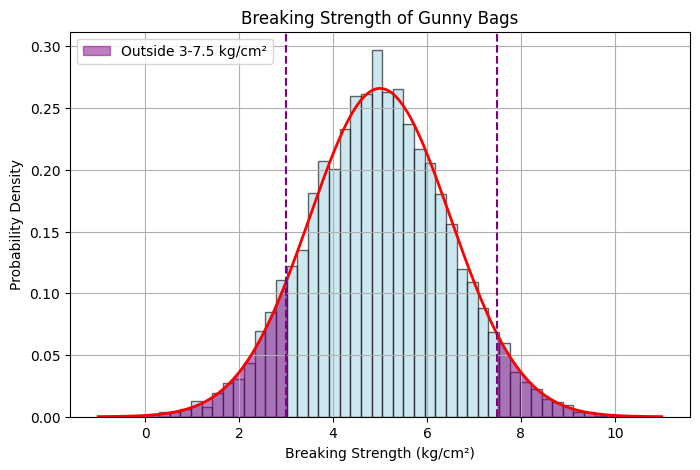

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Given data
mu = 5
sigma = 1.5
X1 = 3
X2 = 7.5

# Step 1: Calculate probability
prob_inside = norm.cdf(X2, mu, sigma) - norm.cdf(X1, mu, sigma)
prob_outside = 1 - prob_inside
print(f"Proportion of bags NOT between {X1} and {X2}: {prob_outside:.4f} ({prob_outside*100:.2f}%)")

# Step 2: Generate random sample for histogram
np.random.seed(0)
samples = np.random.normal(mu, sigma, 10000)

# Step 3: Plot histogram
plt.figure(figsize=(8,5))
plt.hist(samples, bins=50, density=True, alpha=0.6, color='lightblue', edgecolor='black')

# Overlay normal distribution curve
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2)

# Highlight areas outside [X1, X2]
x_left = x[x <= X1]
x_right = x[x >= X2]
plt.fill_between(x_left, norm.pdf(x_left, mu, sigma), 0, color='purple', alpha=0.5, label=f'Outside {X1}-{X2} kg/cm²')
plt.fill_between(x_right, norm.pdf(x_right, mu, sigma), 0, color='purple', alpha=0.5)

# Mark vertical lines
plt.axvline(X1, color='purple', linestyle='--')
plt.axvline(X2, color='purple', linestyle='--')

plt.title('Breaking Strength of Gunny Bags')
plt.xlabel('Breaking Strength (kg/cm²)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()


Z-test / Standard Normal Distribution Test

2.1 P(X < 3.17) = 0.111
2.2 P(X ≥ 3.6) = 0.825
2.3 P(5 ≤ X ≤ 5.5) = 0.131
2.4 P(X not between 3 and 7.5) = 0.139


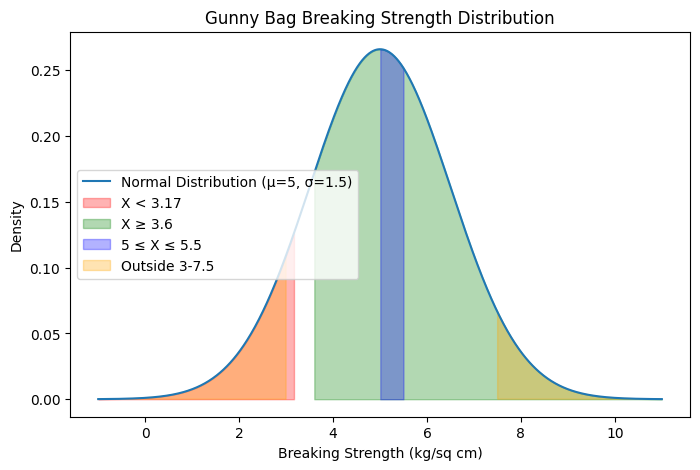

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

# Parameters
mu = 5
sigma = 1.5

# 2.1 P(X < 3.17)
p1 = stats.norm.cdf(3.17, mu, sigma)

# 2.2 P(X ≥ 3.6)
p2 = 1 - stats.norm.cdf(3.6, mu, sigma)

# 2.3 P(5 ≤ X ≤ 5.5)
p3 = stats.norm.cdf(5.5, mu, sigma) - stats.norm.cdf(5, mu, sigma)

# 2.4 P(X not between 3 and 7.5)
p4 = 1 - (stats.norm.cdf(7.5, mu, sigma) - stats.norm.cdf(3, mu, sigma))

print("2.1 P(X < 3.17) =", round(p1,3))
print("2.2 P(X ≥ 3.6) =", round(p2,3))
print("2.3 P(5 ≤ X ≤ 5.5) =", round(p3,3))
print("2.4 P(X not between 3 and 7.5) =", round(p4,3))

# --- Visual Representation ---
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(8,5))
plt.plot(x, y, label="Normal Distribution (μ=5, σ=1.5)")

# Shade regions
plt.fill_between(x, y, where=(x < 3.17), color="red", alpha=0.3, label="X < 3.17")
plt.fill_between(x, y, where=(x >= 3.6), color="green", alpha=0.3, label="X ≥ 3.6")
plt.fill_between(x, y, where=(x >= 5) & (x <= 5.5), color="blue", alpha=0.3, label="5 ≤ X ≤ 5.5")
plt.fill_between(x, y, where=(x <= 3) | (x >= 7.5), color="orange", alpha=0.3, label="Outside 3-7.5")

plt.title("Gunny Bag Breaking Strength Distribution")
plt.xlabel("Breaking Strength (kg/sq cm)")
plt.ylabel("Density")
plt.legend()
plt.show()


Problem 3
Zingaro stone printing is a company that specializes in printing images or patterns on polished or unpolished stones. However, for the optimum level of printing of the image, the stone surface has to have a Brinell's hardness index of at least 150. Recently, Zingaro has received a batch of polished and unpolished stones from its clients. Use the data provided to answer the following (assuming a 5% significance level);

In [ ]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("Zingaro_Company.csv")

# Drop rows with missing values
df_clean = df.dropna()

# Rename columns for clarity (adjust if needed)
df_clean.columns = ['Unpolished', 'Polished']

# Preview cleaned data
print(df_clean.head())



   Unpolished    Polished
0  164.481713  133.209393
1  154.307045  138.482771
2  129.861048  159.665201
3  159.096184  145.663528
4  135.256748  136.789227


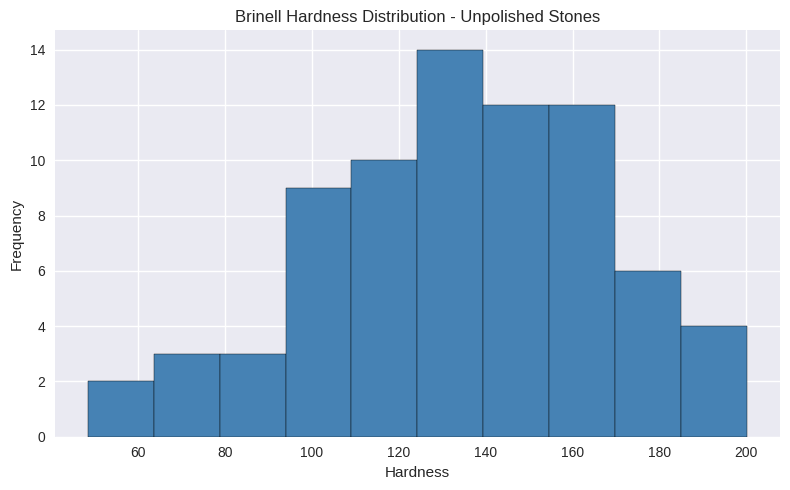

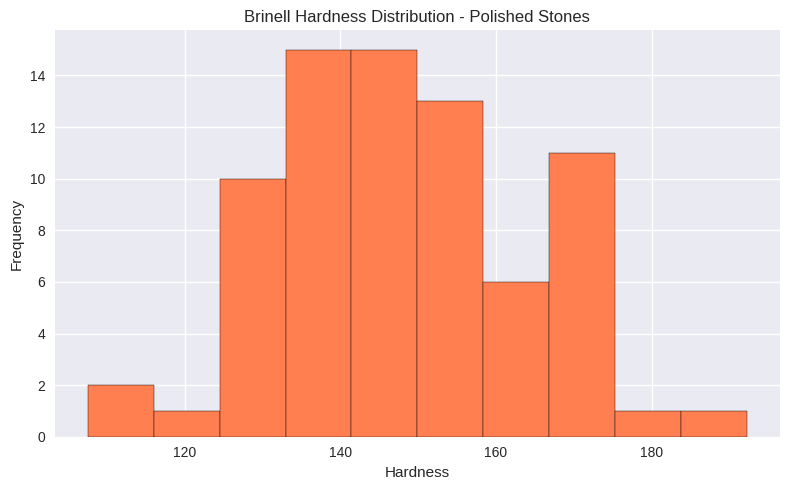

In [ ]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

# Histogram for Unpolished Stones
plt.figure(figsize=(8, 5))
plt.hist(df_clean['Unpolished'], bins=10, color='steelblue', edgecolor='black')
plt.title('Brinell Hardness Distribution - Unpolished Stones')
plt.xlabel('Hardness')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# Histogram for Polished Stones
plt.figure(figsize=(8, 5))
plt.hist(df_clean['Polished'], bins=10, color='coral', edgecolor='black')
plt.title('Brinell Hardness Distribution - Polished Stones')
plt.xlabel('Hardness')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


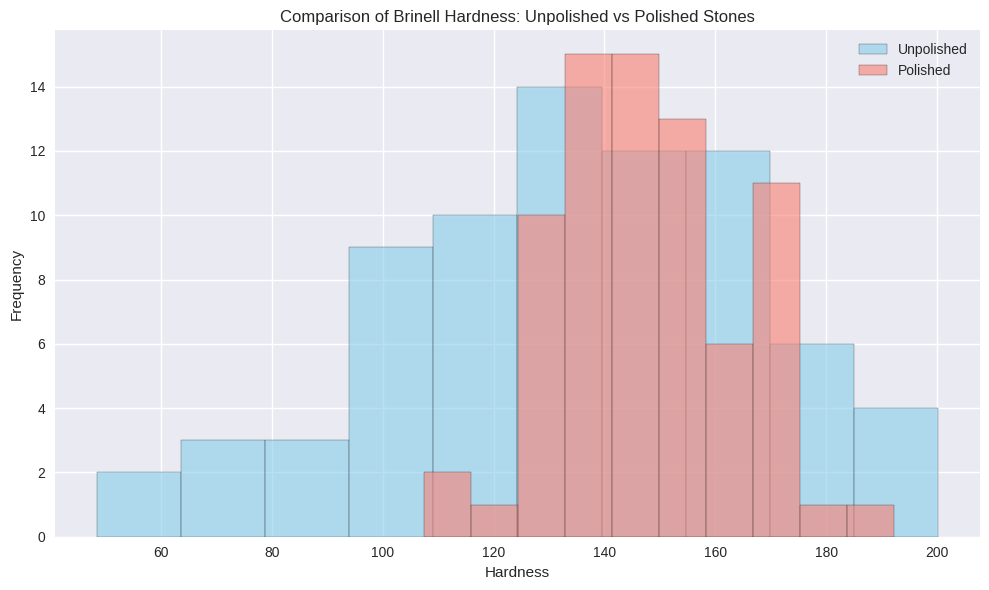

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean['Unpolished'], bins=10, alpha=0.6, label='Unpolished', color='skyblue', edgecolor='black')
plt.hist(df_clean['Polished'], bins=10, alpha=0.6, label='Polished', color='salmon', edgecolor='black')
plt.title('Comparison of Brinell Hardness: Unpolished vs Polished Stones')
plt.xlabel('Hardness')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


3.1 Zingaro has reason to believe that the unpolished stones may not be suitable for printing. Do you think Zingaro is justified in thinking so? State the null and alternate hypotheses

T-statistic: -4.165, P-value: 0.000


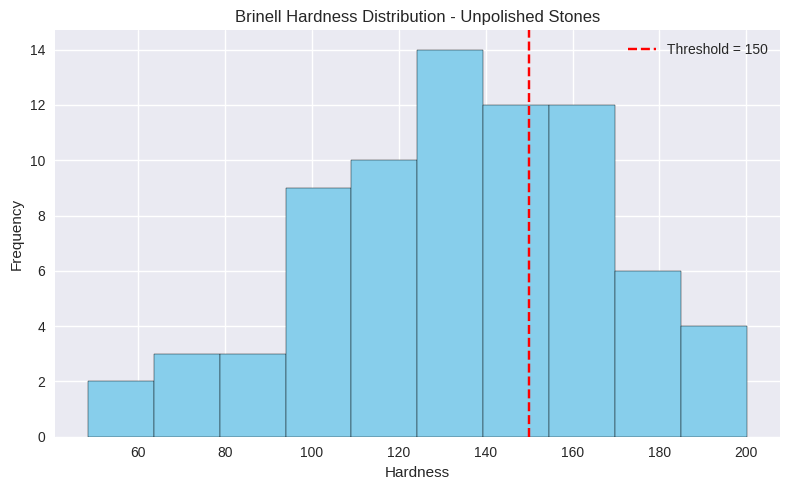

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp

# Load and clean the data
df = pd.read_csv("Zingaro_Company.csv")
df_clean = df.dropna()
df_clean.columns = ['Unpolished', 'Polished']

# Extract unpolished hardness values
unpolished = df_clean['Unpolished']

# Perform one-sample t-test
t_stat, p_val = ttest_1samp(unpolished, popmean=150, alternative='less')
print(f"T-statistic: {t_stat:.3f}, P-value: {p_val:.3f}")

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(unpolished, bins=10, color='skyblue', edgecolor='black')
plt.axvline(x=150, color='red', linestyle='--', label='Threshold = 150')
plt.title('Brinell Hardness Distribution - Unpolished Stones')
plt.xlabel('Hardness')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


3.1 Conducting One-sample t-test

T-statistic: -4.165, P-value: 0.0000


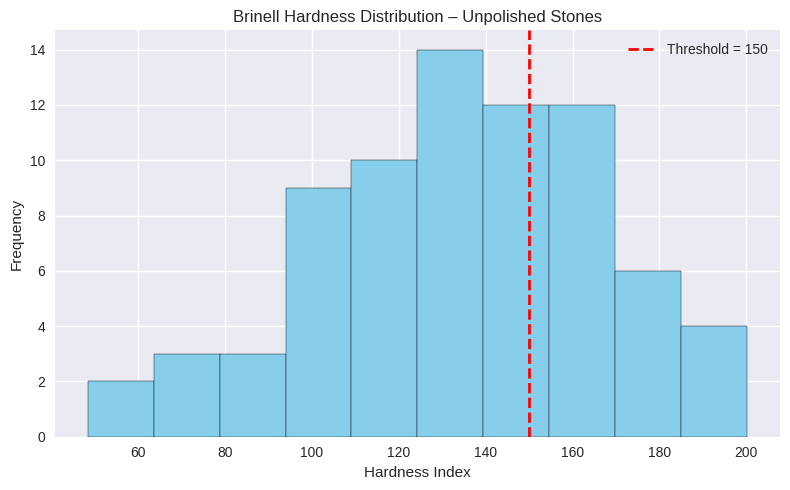

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp

# Load and clean data
df = pd.read_csv("Zingaro_Company.csv")
df.dropna(inplace=True)
df.columns = ['Unpolished', 'Polished']

# Extract unpolished hardness values
unpolished = df['Unpolished']

# One-sample t-test
t_stat, p_val = ttest_1samp(unpolished, popmean=150, alternative='less')
print(f"T-statistic: {t_stat:.3f}, P-value: {p_val:.4f}")

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(unpolished, bins=10, color='skyblue', edgecolor='black')
plt.axvline(x=150, color='red', linestyle='--', linewidth=2, label='Threshold = 150')
plt.title('Brinell Hardness Distribution – Unpolished Stones')
plt.xlabel('Hardness Index')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


3.2 Conducting Two-sample t-test

T-statistic: 3.242, P-value: 0.0016


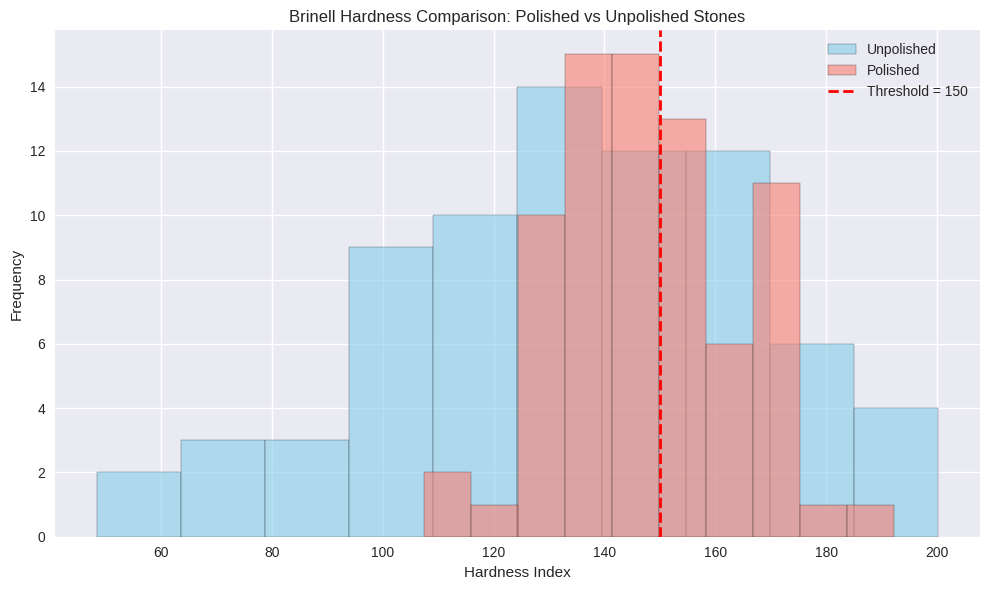

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Load and clean data
df = pd.read_csv("Zingaro_Company.csv")
df.dropna(inplace=True)
df.columns = ['Unpolished', 'Polished']

# Two-sample t-test
t_stat, p_val = ttest_ind(df['Polished'], df['Unpolished'], equal_var=False)
print(f"T-statistic: {t_stat:.3f}, P-value: {p_val:.4f}")

# Side-by-side histograms
plt.figure(figsize=(10, 6))
plt.hist(df['Unpolished'], bins=10, alpha=0.6, label='Unpolished', color='skyblue', edgecolor='black')
plt.hist(df['Polished'], bins=10, alpha=0.6, label='Polished', color='salmon', edgecolor='black')
plt.axvline(x=150, color='red', linestyle='--', linewidth=2, label='Threshold = 150')
plt.title('Brinell Hardness Comparison: Polished vs Unpolished Stones')
plt.xlabel('Hardness Index')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


3.2 State the null and alternate hypotheses. - Conduct the hypothesis test.

In [4]:
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# Load and clean the data
df = pd.read_csv("Zingaro_Company.csv")
df.dropna(inplace=True)
df.columns = ['Unpolished', 'Polished']

# Two-sample t-test (Welch’s t-test for unequal variances)
t_stat, p_val = ttest_ind(df['Polished'], df['Unpolished'], equal_var=False)

# Print results
print("Two-Sample T-Test Results:")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.4f}")

# Conclusion at 5% significance level
if p_val < 0.05:
    print("Conclusion: Reject the null hypothesis. The mean hardness values are significantly different.")
else:
    print("Conclusion: Fail to reject the null hypothesis. No significant difference in mean hardness.")


Two-Sample T-Test Results:
T-statistic: 3.242
P-value: 0.0016
Conclusion: Reject the null hypothesis. The mean hardness values are significantly different.


Tests for One and Two Proportions

One-Proportion Z-Test: Unpolished Stones

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# Load and clean data
df = pd.read_csv("Zingaro_Company.csv")
df.dropna(inplace=True)
df.columns = ['Unpolished', 'Polished']

# Create binary indicator: 1 if hardness ≥ 150, else 0
df['Unpolished_OK'] = np.where(df['Unpolished'] >= 150, 1, 0)

# Count successes and total
successes = df['Unpolished_OK'].sum()
n = len(df['Unpolished_OK'])

# Test if proportion < 0.5
stat, pval = proportions_ztest(count=successes, nobs=n, value=0.5, alternative='smaller')
print(f"One-Proportion Z-Test (Unpolished): Z = {stat:.3f}, p-value = {pval:.4f}")


One-Proportion Z-Test (Unpolished): Z = -3.342, p-value = 0.0004


Two-Proportion Z-Test: Polished vs Unpolished

In [ ]:
# Create binary indicator for polished stones
df['Polished_OK'] = np.where(df['Polished'] >= 150, 1, 0)

# Count successes and totals
successes = [df['Polished_OK'].sum(), df['Unpolished_OK'].sum()]
nobs = [len(df['Polished_OK']), len(df['Unpolished_OK'])]

# Test if proportions are different
stat2, pval2 = proportions_ztest(count=successes, nobs=nobs, alternative='two-sided')
print(f"Two-Proportion Z-Test: Z = {stat2:.3f}, p-value = {pval2:.4f}")


Two-Proportion Z-Test: Z = 1.350, p-value = 0.1769


 Proportion Comparison

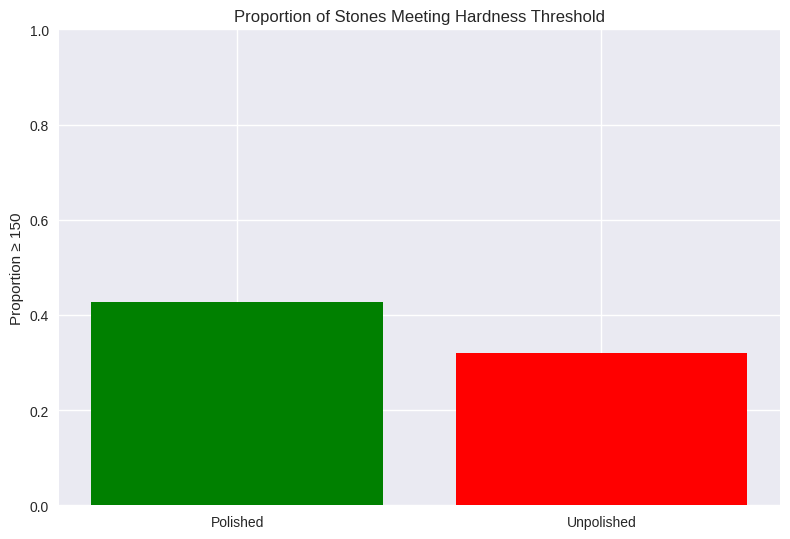

In [ ]:
import matplotlib.pyplot as plt

labels = ['Polished', 'Unpolished']
proportions = [successes[0]/nobs[0], successes[1]/nobs[1]]

plt.bar(labels, proportions, color=['green', 'red'])
plt.title('Proportion of Stones Meeting Hardness Threshold')
plt.ylabel('Proportion ≥ 150')
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()


T-Test Comparison

In [ ]:
import pandas as pd
import scipy.stats as stats

# Load dataset
df = pd.read_csv("Zingaro_Company.csv")

# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# Groups
unpolished = df["unpolished"]
polished = df["treated_and_polished"]

# --- Problem 3.1: One-sample t-test vs 150 ---
t_stat, p_val_two_tailed = stats.ttest_1samp(unpolished, 150)

# Convert to one-tailed (H1: mean < 150)
if t_stat < 0:
    p_val_one_tailed = p_val_two_tailed / 2
else:
    p_val_one_tailed = 1 - (p_val_two_tailed / 2)

print("3.1 One-sample t-test (Unpolished vs 150):")
print(f"t = {t_stat:.3f}, one-tailed p = {p_val_one_tailed:.4f}")

# --- Problem 3.2: Two-sample t-test (Welch’s test) ---
t_stat2, p_val2 = stats.ttest_ind(unpolished, polished, equal_var=False)

print("\n3.2 Two-sample t-test (Unpolished vs Polished):")
print(f"t = {t_stat2:.3f}, two-tailed p = {p_val2:.4f}")


3.1 One-sample t-test (Unpolished vs 150):
t = -4.165, one-tailed p = 0.0000

3.2 Two-sample t-test (Unpolished vs Polished):
t = -3.242, two-tailed p = 0.0016


Problem 4. Dental implant data: The hardness of metal implants in dental cavities depends on multiple factors, such as the method of implant, the temperature at which the metal is treated, the alloy used as well as the dentists who may favor one method above another and may work better in his/her favorite method. The response is the variable of interest.

In [ ]:
import pandas as pd

# Load the Excel file
df = pd.read_excel("Dental Hardness data.xlsx")

# Preview the data
print("Initial Data Snapshot:")
print(df.head())

# Step 1: Remove rows with missing values
df_clean = df.dropna()

# Step 2: Standardize column names
df_clean.columns = df_clean.columns.str.strip().str.replace(' ', '_').str.lower()

# Step 3: Check for duplicates
df_clean = df_clean.drop_duplicates()

# Step 4: Ensure correct data types
df_clean['dentist'] = df_clean['dentist'].astype(int)
df_clean['response'] = pd.to_numeric(df_clean['response'], errors='coerce')

# Step 5: Remove any rows with invalid hardness values (e.g., negative or zero)
df_clean = df_clean[df_clean['response'] > 0]

# Final check
print("\nCleaned Data Summary:")
print(df_clean.describe())


Initial Data Snapshot:
   Dentist  Method  Alloy  Temp  Response
0        1       1      1  1500       813
1        1       1      1  1600       792
2        1       1      1  1700       792
3        1       1      2  1500       907
4        1       1      2  1600       792

Cleaned Data Summary:
         dentist     method      alloy         temp     response
count  90.000000  90.000000  90.000000    90.000000    90.000000
mean    3.000000   2.000000   1.500000  1600.000000   741.777778
std     1.422136   0.821071   0.502801    82.107083   145.767845
min     1.000000   1.000000   1.000000  1500.000000   289.000000
25%     2.000000   1.000000   1.000000  1500.000000   698.000000
50%     3.000000   2.000000   1.500000  1600.000000   767.000000
75%     4.000000   3.000000   2.000000  1700.000000   824.000000
max     5.000000   3.000000   2.000000  1700.000000  1115.000000


4.1 How does the hardness of implants vary depending on dentists?

In [16]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro, levene, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings("ignore")

# Load the dataset
df = pd.read_excel("Dental Hardness data.xlsx")

# Get unique alloy types
alloy_types = df['Alloy'].unique()

for alloy in alloy_types:
    print(f"\n Analyzing Alloy Type: {alloy}")
    alloy_df = df[df['Alloy'] == alloy]
    dentists = alloy_df['Dentist'].unique()

    # 1. Shapiro-Wilk Test for Normality
    print("\n Shapiro-Wilk Test (Normality by Dentist):")
    for dentist in dentists:
        group = alloy_df[alloy_df['Dentist'] == dentist]['Response']
        stat, p = shapiro(group)
        print(f"Dentist {dentist}: Statistic = {stat:.4f}, p-value = {p:.4f}")

    # 2. Levene’s Test for Equal Variance
    print("\n Levene’s Test (Equal Variance):")
    groups = [alloy_df[alloy_df['Dentist'] == d]['Response'] for d in dentists]
    stat, p = levene(*groups)
    print(f"Levene Statistic = {stat:.4f}, p-value = {p:.4f}")

    # 3. One-way ANOVA
    print("\n One-way ANOVA (Hardness by Dentist):")
    stat, p = f_oneway(*groups)
    print(f"ANOVA F-statistic = {stat:.4f}, p-value = {p:.4f}")

    # 4. Tukey’s HSD if ANOVA is significant
    if p < 0.05:
        print("\n Tukey’s HSD (Post-hoc Comparison):")
        tukey = pairwise_tukeyhsd(endog=alloy_df['Response'], groups=alloy_df['Dentist'], alpha=0.05)
        print(tukey.summary())
    else:
        print("\n No significant difference in hardness across dentists for this alloy.")



 Analyzing Alloy Type: 1

 Shapiro-Wilk Test (Normality by Dentist):
Dentist 1: Statistic = 0.9114, p-value = 0.3255
Dentist 2: Statistic = 0.9642, p-value = 0.8415
Dentist 3: Statistic = 0.8721, p-value = 0.1295
Dentist 4: Statistic = 0.8369, p-value = 0.0533
Dentist 5: Statistic = 0.8534, p-value = 0.0813

 Levene’s Test (Equal Variance):
Levene Statistic = 1.3847, p-value = 0.2566

 One-way ANOVA (Hardness by Dentist):
ANOVA F-statistic = 1.9771, p-value = 0.1166

 No significant difference in hardness across dentists for this alloy.

 Analyzing Alloy Type: 2

 Shapiro-Wilk Test (Normality by Dentist):
Dentist 1: Statistic = 0.9040, p-value = 0.2759
Dentist 2: Statistic = 0.9392, p-value = 0.5735
Dentist 3: Statistic = 0.9341, p-value = 0.5213
Dentist 4: Statistic = 0.7613, p-value = 0.0073
Dentist 5: Statistic = 0.9132, p-value = 0.3386

 Levene’s Test (Equal Variance):
Levene Statistic = 1.4456, p-value = 0.2369

 One-way ANOVA (Hardness by Dentist):
ANOVA F-statistic = 0.5248, p

Hardness Summary by Dentist:
   Dentist        mean  min   max         std
0        1  783.055556  560  1115  129.281486
1        2  786.666667  673   933   77.431564
2        3  748.611111  613   858   69.725629
3        4  713.666667  289   894  178.209064
4        5  676.888889  312  1048  206.468881


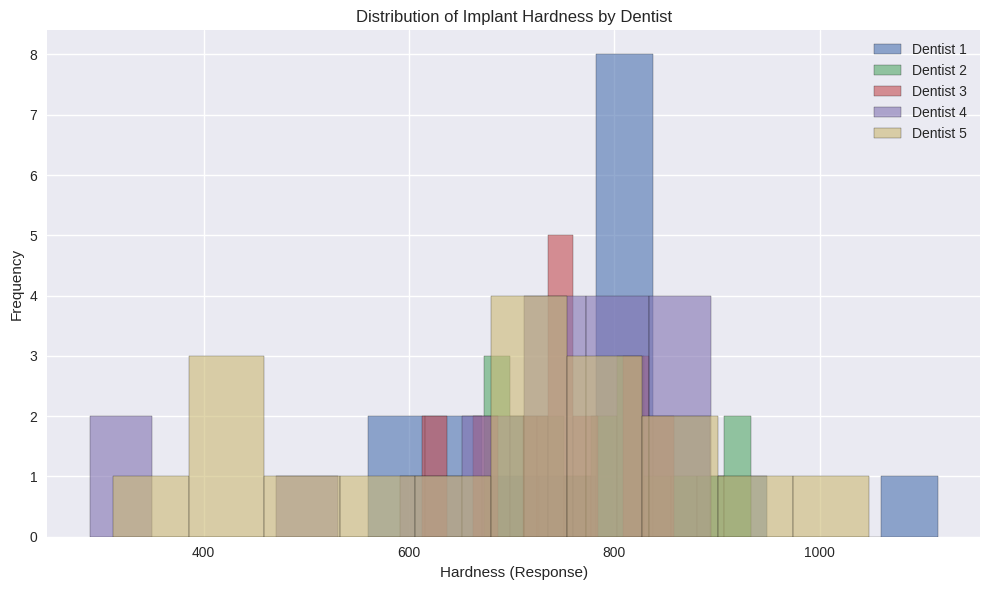

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and clean data
df = pd.read_excel("Dental Hardness data.xlsx")
df.dropna(inplace=True)

# Summary statistics by dentist
summary = df.groupby('Dentist')['Response'].agg(['mean', 'min', 'max', 'std']).reset_index()
print("Hardness Summary by Dentist:")
print(summary)

# Histogram: Hardness distribution by dentist
plt.figure(figsize=(10, 6))
for dentist_id in sorted(df['Dentist'].unique()):
    subset = df[df['Dentist'] == dentist_id]['Response']
    plt.hist(subset, bins=10, alpha=0.6, label=f'Dentist {dentist_id}', edgecolor='black')

plt.title('Distribution of Implant Hardness by Dentist')
plt.xlabel('Hardness (Response)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


4.1 (a) The assumptions of the hypothesis test were checked, and the test was conducted with the corresponding p-value computed. Based on the results, appropriate conclusions were drawn. In cases where implant hardness differed, the specific pairs showing significant differences were identified.

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load and clean data
df = pd.read_excel("Dental Hardness data.xlsx")
df.columns = df.columns.str.strip().str.lower()
df.dropna(inplace=True)

# Run ANOVA separately for each alloy
for alloy_type in [1, 2]:
    print(f"\n--- Alloy Type {alloy_type} ---")
    df_subset = df[df['alloy'] == alloy_type]

    # ANOVA model
    model = ols('response ~ C(dentist)', data=df_subset).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("ANOVA Results:")
    print(anova_table)

    # Extract p-value
    p_value = anova_table['PR(>F)'][0]
    if p_value < 0.05:
        print("Conclusion: Reject H₀. Implant hardness differs across dentists.")
    else:
        print("Conclusion: Fail to reject H₀. No significant difference in hardness.")

    # Tukey HSD for pairwise comparisons
    tukey = pairwise_tukeyhsd(endog=df_subset['response'],
                              groups=df_subset['dentist'],
                              alpha=0.05)
    print("\nTukey HSD Pairwise Comparisons:")
    print(tukey.summary())



--- Alloy Type 1 ---
ANOVA Results:
                   sum_sq    df         F    PR(>F)
C(dentist)  106683.688889   4.0  1.977112  0.116567
Residual    539593.555556  40.0       NaN       NaN
Conclusion: Fail to reject H₀. No significant difference in hardness.


/tmp/ipython-input-1799541034.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]



Tukey HSD Pairwise Comparisons:
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     1      2   11.3333 0.9996 -145.0423  167.709  False
     1      3  -32.3333 0.9757  -188.709 124.0423  False
     1      4  -68.7778 0.7189 -225.1535  87.5979  False
     1      5 -122.2222 0.1889 -278.5979  34.1535  False
     2      3  -43.6667 0.9298 -200.0423  112.709  False
     2      4  -80.1111 0.5916 -236.4868  76.2646  False
     2      5 -133.5556 0.1258 -289.9312  22.8201  False
     3      4  -36.4444 0.9626 -192.8201 119.9312  False
     3      5  -89.8889 0.4805 -246.2646  66.4868  False
     4      5  -53.4444 0.8643 -209.8201 102.9312  False
--------------------------------------------------------

--- Alloy Type 2 ---
ANOVA Results:
                  sum_sq    df         F    PR(>F)
C(dentist)  5.679791e+04   4.0  0.524835  0.718031
Residual    1.082205e+06  40.0

/tmp/ipython-input-1799541034.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]



Tukey HSD Pairwise Comparisons:
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     1      2  -4.1111    1.0 -225.5687 217.3465  False
     1      3 -36.5556 0.9895 -258.0131  184.902  False
     1      4    -70.0 0.8941 -291.4576 151.4576  False
     1      5 -90.1111 0.7724 -311.5687 131.3465  False
     2      3 -32.4444 0.9933  -253.902 189.0131  False
     2      4 -65.8889 0.9132 -287.3465 155.5687  False
     2      5    -86.0 0.8008 -307.4576 135.4576  False
     3      4 -33.4444 0.9925  -254.902 188.0131  False
     3      5 -53.5556 0.9574 -275.0131  167.902  False
     4      5 -20.1111  0.999 -241.5687 201.3465  False
-------------------------------------------------------


4.1 (b) Evaluataing Hardness by Dentist for Each Alloy

/tmp/ipython-input-2961236376.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dentist', y='response', data=df_subset, palette='Set2')


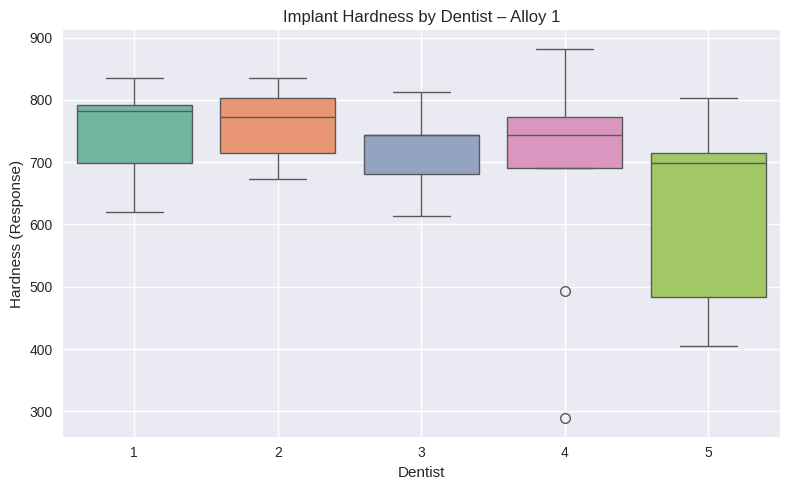

/tmp/ipython-input-2961236376.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dentist', y='response', data=df_subset, palette='Set2')


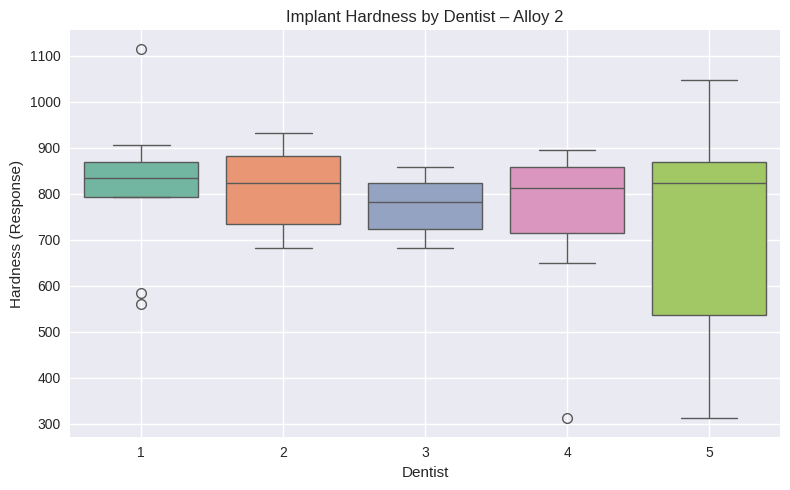

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean the data
df = pd.read_excel("Dental Hardness data.xlsx")
df.columns = df.columns.str.strip().str.lower()
df.dropna(inplace=True)

# Loop through each alloy type
for alloy_type in sorted(df['alloy'].unique()):
    df_subset = df[df['alloy'] == alloy_type]

    plt.figure(figsize=(8, 5))
    sns.boxplot(x='dentist', y='response', data=df_subset, palette='Set2')

    plt.title(f'Implant Hardness by Dentist – Alloy {alloy_type}')
    plt.xlabel('Dentist')
    plt.ylabel('Hardness (Response)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


4.2 How does the hardness of implants vary depending on methods?

ANOVA Results:
                 sum_sq    df         F        PR(>F)
C(method)  5.934275e+05   2.0  19.89268  7.683892e-08
Residual   1.297668e+06  87.0       NaN           NaN

Tukey HSD Pairwise Comparisons:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
     1      2   10.4333 0.9415  -64.7584   85.6251  False
     1      3    -166.8    0.0 -241.9917  -91.6083   True
     2      3 -177.2333    0.0 -252.4251 -102.0416   True
---------------------------------------------------------


/tmp/ipython-input-2802243444.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='method', y='response', data=df, palette='Set3')


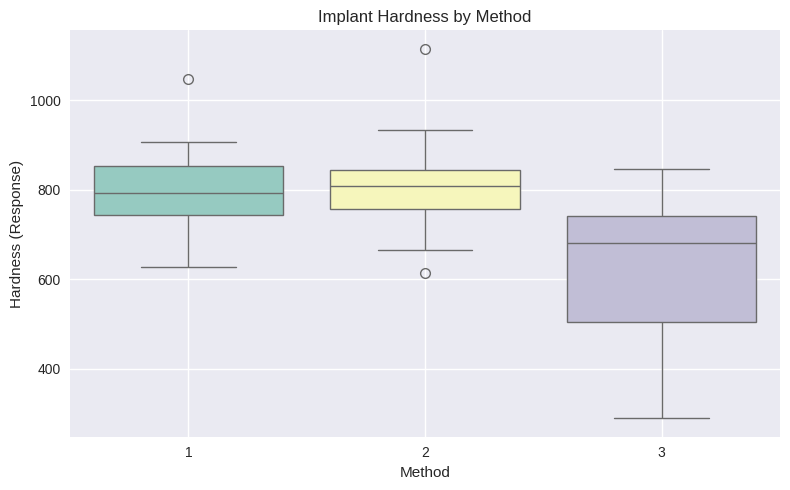

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt

# Load and clean data
df = pd.read_excel("Dental Hardness data.xlsx")
df.columns = df.columns.str.strip().str.lower()
df.dropna(inplace=True)

# ANOVA model
model = ols('response ~ C(method)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA Results:")
print(anova_table)

# Tukey HSD
tukey = pairwise_tukeyhsd(endog=df['response'], groups=df['method'], alpha=0.05)
print("\nTukey HSD Pairwise Comparisons:")
print(tukey.summary())

# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='method', y='response', data=df, palette='Set3')
plt.title('Implant Hardness by Method')
plt.xlabel('Method')
plt.ylabel('Hardness (Response)')
plt.grid(True)
plt.tight_layout()
plt.show()


4.2 (a) State the null and alternate hypotheses
- Check the assumptions of the hypothesis test.
- Conduct the hypothesis test and compute the p-value
- In case the implant hardness differs, identify for which pairs it differs


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load and clean data
df = pd.read_excel("Dental Hardness data.xlsx")
df.columns = df.columns.str.strip().str.lower()
df.dropna(inplace=True)

# Run ANOVA separately for each alloy
for alloy_type in [1, 2]:
    print(f"\n--- Alloy Type {alloy_type} ---")
    df_subset = df[df['alloy'] == alloy_type]

    # ANOVA model
    model = ols('response ~ C(method)', data=df_subset).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("ANOVA Results:")
    print(anova_table)

    # Extract p-value
    p_value = anova_table['PR(>F)'][0]
    if p_value < 0.05:
        print("Conclusion: Reject H₀. Implant hardness differs across methods.")
    else:
        print("Conclusion: Fail to reject H₀. No significant difference in hardness.")

    # Tukey HSD for pairwise comparisons
    tukey = pairwise_tukeyhsd(endog=df_subset['response'],
                              groups=df_subset['method'],
                              alpha=0.05)
    print("\nTukey HSD Pairwise Comparisons:")
    print(tukey.summary())



--- Alloy Type 1 ---
ANOVA Results:
                  sum_sq    df         F    PR(>F)
C(method)  148472.177778   2.0  6.263327  0.004163
Residual   497805.066667  42.0       NaN       NaN
Conclusion: Reject H₀. Implant hardness differs across methods.


/tmp/ipython-input-2823008983.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]



Tukey HSD Pairwise Comparisons:
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     1      2   -6.1333  0.987  -102.714  90.4473  False
     1      3    -124.8 0.0085 -221.3807 -28.2193   True
     2      3 -118.6667 0.0128 -215.2473  -22.086   True
--------------------------------------------------------

--- Alloy Type 2 ---
ANOVA Results:
             sum_sq    df        F    PR(>F)
C(method)  499640.4   2.0  16.4108  0.000005
Residual   639362.4  42.0      NaN       NaN
Conclusion: Reject H₀. Implant hardness differs across methods.


/tmp/ipython-input-2823008983.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]



Tukey HSD Pairwise Comparisons:
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2 meandiff p-adj    lower     upper   reject
--------------------------------------------------------
     1      2     27.0 0.8212  -82.4546  136.4546  False
     1      3   -208.8 0.0001 -318.2546  -99.3454   True
     2      3   -235.8    0.0 -345.2546 -126.3454   True
--------------------------------------------------------


4.3 What is the interaction effect between the dentist and method on the hardness of dental implants for each type of alloy?
"- Create Interaction Plot


/tmp/ipython-input-2654412593.py:15: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.pointplot(x='method', y='response', hue='dentist', data=df_subset,


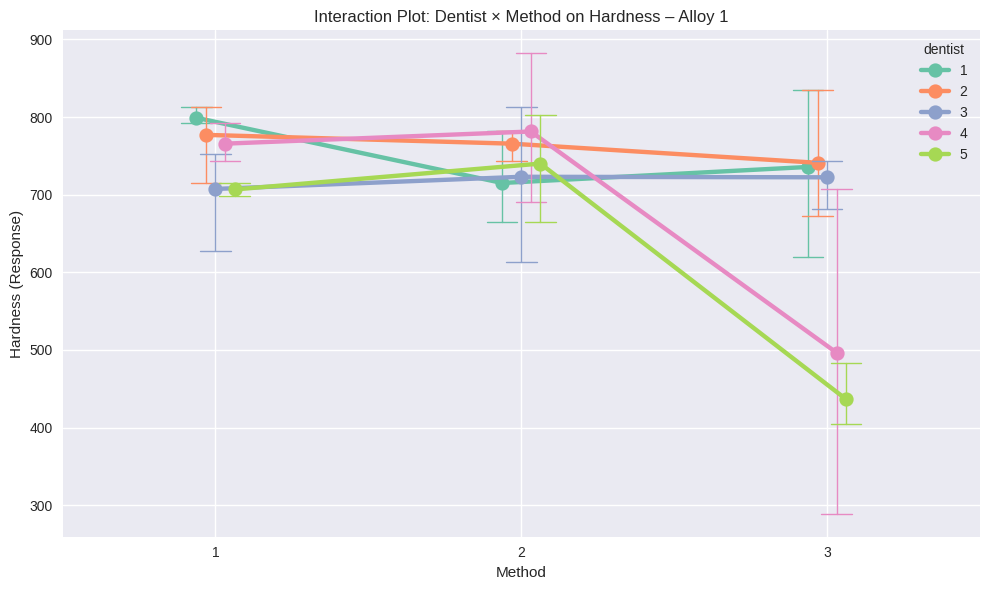

/tmp/ipython-input-2654412593.py:15: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.pointplot(x='method', y='response', hue='dentist', data=df_subset,


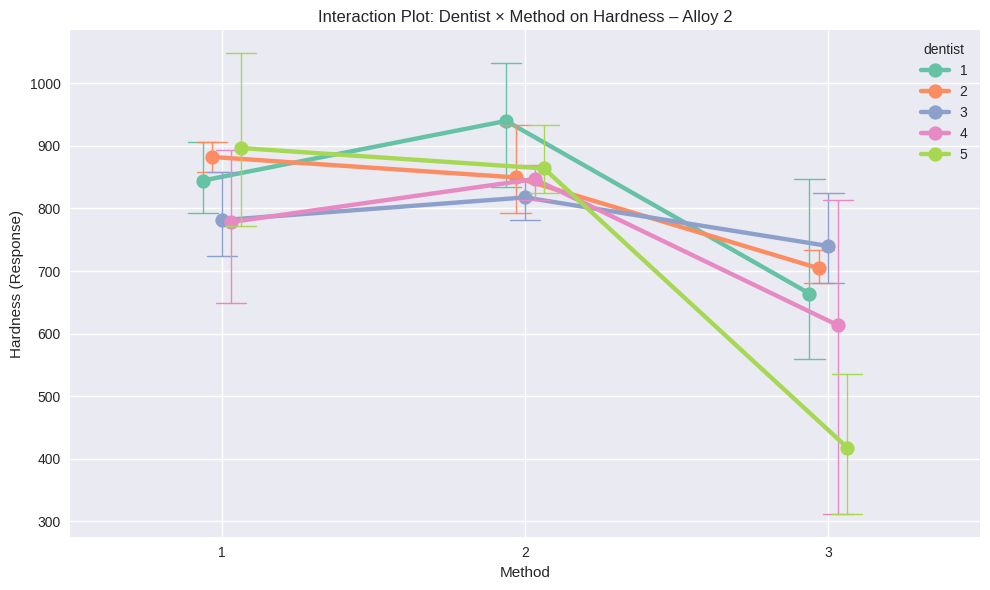

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean data
df = pd.read_excel("Dental Hardness data.xlsx")
df.columns = df.columns.str.strip().str.lower()
df.dropna(inplace=True)

# Create interaction plots for each alloy
for alloy_type in sorted(df['alloy'].unique()):
    df_subset = df[df['alloy'] == alloy_type]

    plt.figure(figsize=(10, 6))
    sns.pointplot(x='method', y='response', hue='dentist', data=df_subset,
                  dodge=True, markers='o', capsize=.1, errwidth=1, palette='Set2')

    plt.title(f'Interaction Plot: Dentist × Method on Hardness – Alloy {alloy_type}')
    plt.xlabel('Method')
    plt.ylabel('Hardness (Response)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


4.3 (a)Two-Way ANOVA Test + Interaction Plot


--- Alloy Type 1 ---
Two-Way ANOVA Results:
                             sum_sq    df          F    PR(>F)
C(dentist)            106683.688889   4.0   3.899638  0.011484
C(method)             148472.177778   2.0  10.854287  0.000284
C(dentist):C(method)  185941.377778   8.0   3.398383  0.006793
Residual              205180.000000  30.0        NaN       NaN


/tmp/ipython-input-2560091257.py:25: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.pointplot(x='method', y='response', hue='dentist', data=df_subset,


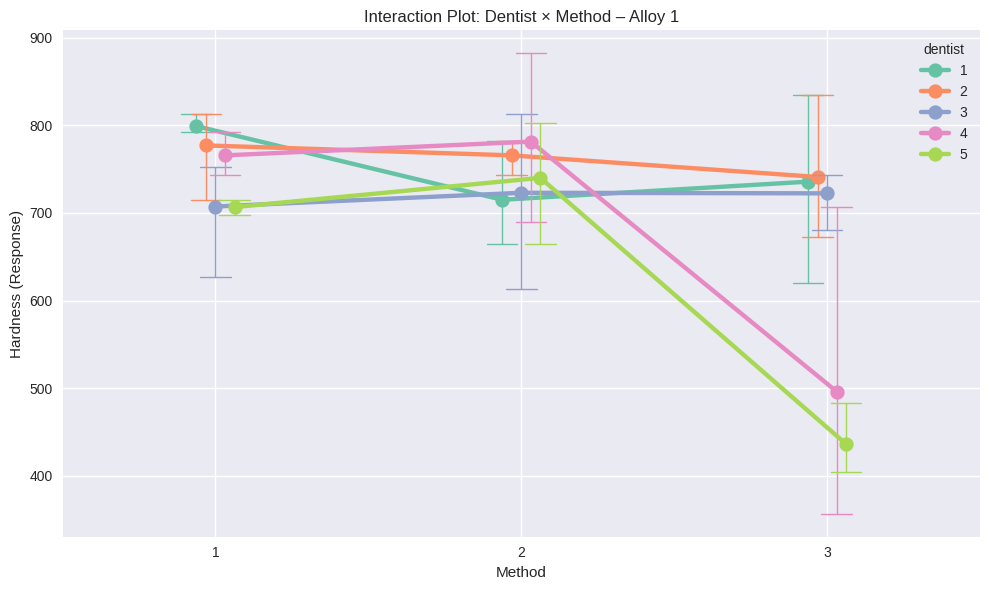


--- Alloy Type 2 ---
Two-Way ANOVA Results:
                             sum_sq    df          F    PR(>F)
C(dentist)             56797.911111   4.0   1.106152  0.371833
C(method)             499640.400000   2.0  19.461218  0.000004
C(dentist):C(method)  197459.822222   8.0   1.922787  0.093234
Residual              385104.666667  30.0        NaN       NaN


/tmp/ipython-input-2560091257.py:25: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.pointplot(x='method', y='response', hue='dentist', data=df_subset,


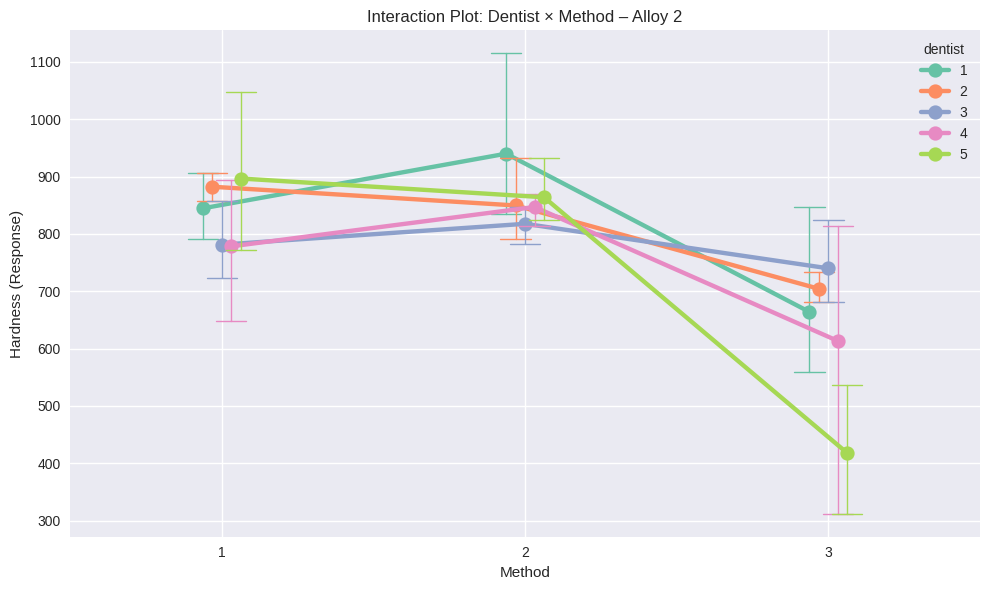

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean data
df = pd.read_excel("Dental Hardness data.xlsx")
df.columns = df.columns.str.strip().str.lower()
df.dropna(inplace=True)

# Run analysis separately for each alloy
for alloy_type in sorted(df['alloy'].unique()):
    print(f"\n--- Alloy Type {alloy_type} ---")
    df_subset = df[df['alloy'] == alloy_type]

    # Two-way ANOVA model with interaction
    model = ols('response ~ C(dentist) * C(method)', data=df_subset).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("Two-Way ANOVA Results:")
    print(anova_table)

    # Interaction plot
    plt.figure(figsize=(10, 6))
    sns.pointplot(x='method', y='response', hue='dentist', data=df_subset,
                  dodge=True, markers='o', capsize=.1, errwidth=1, palette='Set2')
    plt.title(f'Interaction Plot: Dentist × Method – Alloy {alloy_type}')
    plt.xlabel('Method')
    plt.ylabel('Hardness (Response)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


4.4 How does the hardness of implants vary depending on dentists and methods together?




--- Alloy Type 1 ---
Two-Way ANOVA Results:
                             sum_sq    df          F    PR(>F)
C(dentist)            106683.688889   4.0   3.899638  0.011484
C(method)             148472.177778   2.0  10.854287  0.000284
C(dentist):C(method)  185941.377778   8.0   3.398383  0.006793
Residual              205180.000000  30.0        NaN       NaN


/tmp/ipython-input-1000184249.py:29: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.pointplot(x='method', y='response', hue='dentist', data=df_subset,


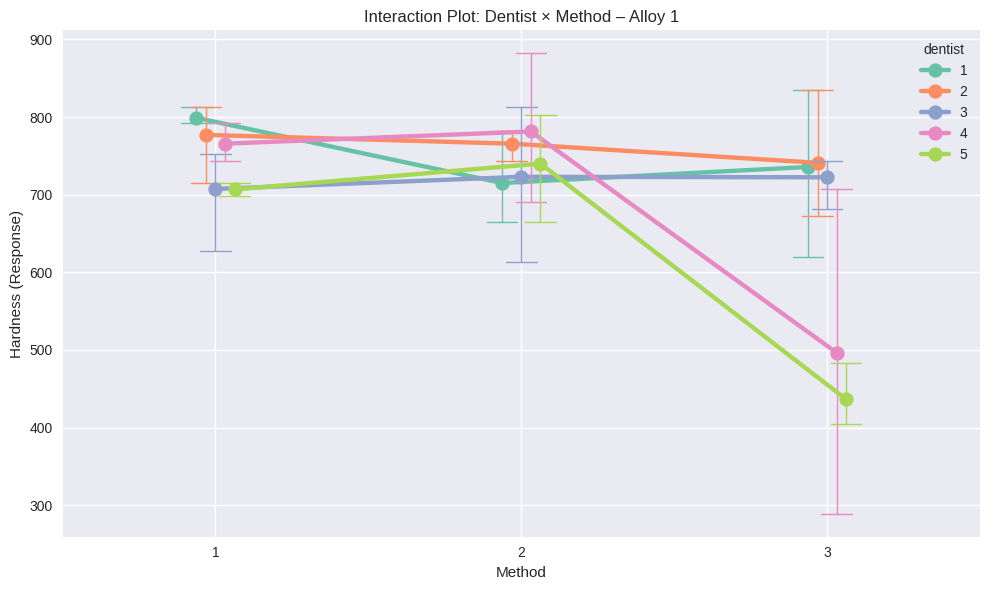


Tukey HSD on Dentist × Method combinations:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
   1_1    1_2     -84.0 0.9933 -332.8283  164.8283  False
   1_1    1_3  -63.3333 0.9996 -312.1617   185.495  False
   1_1    2_1     -22.0    1.0 -270.8283  226.8283  False
   1_1    2_2  -33.3333    1.0 -282.1617   215.495  False
   1_1    2_3     -58.0 0.9999 -306.8283  190.8283  False
   1_1    3_1  -91.6667 0.9853  -340.495  157.1617  False
   1_1    3_2     -76.0 0.9975 -324.8283  172.8283  False
   1_1    3_3  -76.6667 0.9972  -325.495  172.1617  False
   1_1    4_1  -33.3333    1.0 -282.1617   215.495  False
   1_1    4_2  -17.6667    1.0  -266.495  231.1617  False
   1_1    4_3 -302.6667  0.007  -551.495  -53.8383   True
   1_1    5_1  -92.3333 0.9844 -341.1617   156.495  False
   1_1    5_2     -59.0 0.9998 -307.8283  189.8283  False
   1_1    5_3 -362.6667 0.0

/tmp/ipython-input-1000184249.py:29: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.pointplot(x='method', y='response', hue='dentist', data=df_subset,


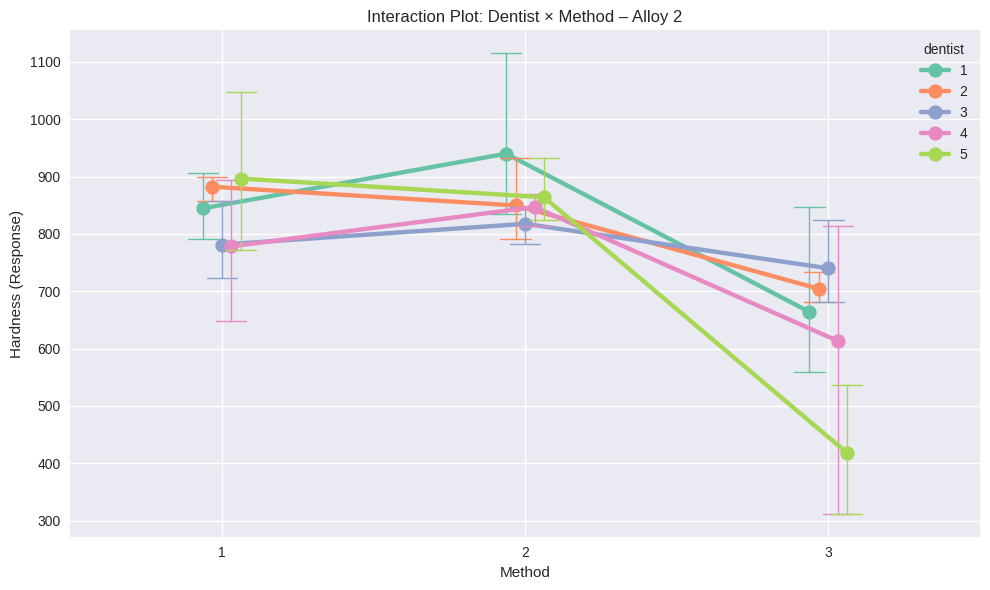


Tukey HSD on Dentist × Method combinations:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
   1_1    1_2   95.3333  0.999 -245.5625  436.2292  False
   1_1    1_3 -180.6667 0.8085 -521.5625  160.2292  False
   1_1    2_1   37.6667    1.0 -303.2292  378.5625  False
   1_1    2_2       5.0    1.0 -335.8958  345.8958  False
   1_1    2_3 -140.3333 0.9635 -481.2292  200.5625  False
   1_1    3_1  -63.3333    1.0 -404.2292  277.5625  False
   1_1    3_2     -27.0    1.0 -367.8958  313.8958  False
   1_1    3_3 -104.6667 0.9973 -445.5625  236.2292  False
   1_1    4_1  -66.3333    1.0 -407.2292  274.5625  False
   1_1    4_2    2.3333    1.0 -338.5625  343.2292  False
   1_1    4_3 -231.3333 0.4686 -572.2292  109.5625  False
   1_1    5_1      52.0    1.0 -288.8958  392.8958  False
   1_1    5_2   19.3333    1.0 -321.5625  360.2292  False
   1_1    5_3    -427.0 0.0

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import MultiComparison
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean the data
df = pd.read_excel("Dental Hardness data.xlsx")
df.columns = df.columns.str.strip().str.lower()
df.dropna(inplace=True)

# Run analysis separately for each alloy
for alloy_type in sorted(df['alloy'].unique()):
    print(f"\n--- Alloy Type {alloy_type} ---")
    df_subset = df[df['alloy'] == alloy_type].copy()

    # Create interaction term for post-hoc comparison
    df_subset['dentist_method'] = df_subset['dentist'].astype(str) + "_" + df_subset['method'].astype(str)

    # Two-way ANOVA model with interaction
    model = ols('response ~ C(dentist) * C(method)', data=df_subset).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("Two-Way ANOVA Results:")
    print(anova_table)

    # Interaction plot
    plt.figure(figsize=(10, 6))
    sns.pointplot(x='method', y='response', hue='dentist', data=df_subset,
                  dodge=True, markers='o', capsize=.1, errwidth=1, palette='Set2')
    plt.title(f'Interaction Plot: Dentist × Method – Alloy {alloy_type}')
    plt.xlabel('Method')
    plt.ylabel('Hardness (Response)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Tukey HSD on dentist-method combinations
    print("\nTukey HSD on Dentist × Method combinations:")
    mc = MultiComparison(df_subset['response'], df_subset['dentist_method'])
    tukey_result = mc.tukeyhsd()
    print(tukey_result.summary())



4.4 (a) Evaluating Dental Hardness

   Dentist  Method  Alloy  Temp  Response
0        1       1      1  1500       813
1        1       1      1  1600       792
2        1       1      1  1700       792
3        1       1      2  1500       907
4        1       1      2  1600       792

Shapiro-Wilk Test by Method:
Method 1: W = 0.9652, p = 0.4184
Method 2: W = 0.9371, p = 0.0760
Method 3: W = 0.9092, p = 0.0142

 Levene’s Test across Methods:
Levene’s Statistic = 5.8486, p-value = 0.0041

 ANOVA Results:
                 sum_sq    df          F        PR(>F)
C(Method)  5.934275e+05   2.0  22.460599  1.534999e-08
C(Alloy)   1.058155e+05   1.0   8.010009  5.818378e-03
C(Temp)    8.217802e+04   2.0   3.110351  4.975877e-02
Residual   1.109675e+06  84.0        NaN           NaN


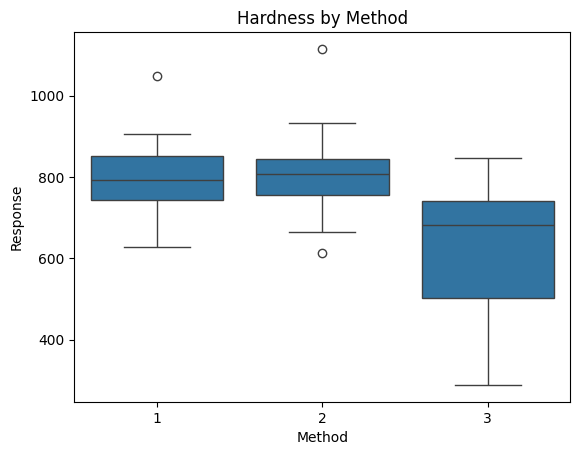

In [6]:
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Load the data
df = pd.read_excel("Dental Hardness data.xlsx")

# Preview
print(df.head())

# 1️Shapiro-Wilk Test for Normality (grouped by Method)
print("\nShapiro-Wilk Test by Method:")
for method in df['Method'].unique():
    group = df[df['Method'] == method]['Response']
    stat, p = stats.shapiro(group)
    print(f"Method {method}: W = {stat:.4f}, p = {p:.4f}")

# 2️Levene’s Test for Equal Variances (across Methods)
print("\n Levene’s Test across Methods:")
groups = [df[df['Method'] == m]['Response'] for m in df['Method'].unique()]
levene_stat, levene_p = stats.levene(*groups)
print(f"Levene’s Statistic = {levene_stat:.4f}, p-value = {levene_p:.4f}")

# 3 ANOVA Test
model = ols('Response ~ C(Method) + C(Alloy) + C(Temp)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("\n ANOVA Results:")
print(anova_table)

# Optional: Visualize distributions
sns.boxplot(x='Method', y='Response', data=df)
plt.title("Hardness by Method")
plt.show()


4.4 (b) Alloy Type Analysis


 Alloy Type 1 Analysis
Shapiro-Wilk p-value: 0.0902
Levene’s p-value: 0.2566

ANOVA Results:
                              sum_sq    df          F    PR(>F)
C(Dentist)            106683.688889   4.0   3.899638  0.011484
C(Method)             148472.177778   2.0  10.854287  0.000284
C(Dentist):C(Method)  185941.377778   8.0   3.398383  0.006793
Residual              205180.000000  30.0        NaN       NaN

Tukey HSD Results:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     1      2   11.3333 0.9996 -145.0423  167.709  False
     1      3  -32.3333 0.9757  -188.709 124.0423  False
     1      4  -68.7778 0.7189 -225.1535  87.5979  False
     1      5 -122.2222 0.1889 -278.5979  34.1535  False
     2      3  -43.6667 0.9298 -200.0423  112.709  False
     2      4  -80.1111 0.5916 -236.4868  76.2646  False
     2      5 -133.5556 0.1258 -289.9312  22.8201  False

/tmp/ipython-input-4220565509.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(x="Method", y="Response", hue="Dentist", data=data,


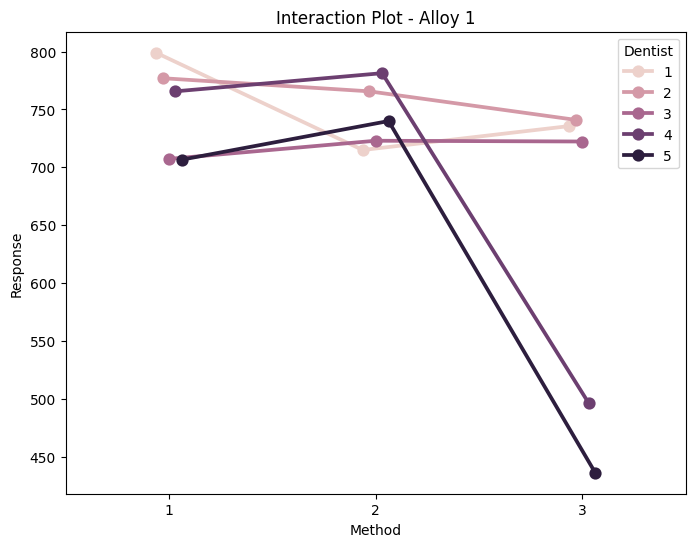


 Alloy Type 2 Analysis
Shapiro-Wilk p-value: 0.0946
Levene’s p-value: 0.2369

ANOVA Results:
                              sum_sq    df          F    PR(>F)
C(Dentist)             56797.911111   4.0   1.106152  0.371833
C(Method)             499640.400000   2.0  19.461218  0.000004
C(Dentist):C(Method)  197459.822222   8.0   1.922787  0.093234
Residual              385104.666667  30.0        NaN       NaN

Tukey HSD Results:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     1      2  -4.1111    1.0 -225.5687 217.3465  False
     1      3 -36.5556 0.9895 -258.0131  184.902  False
     1      4    -70.0 0.8941 -291.4576 151.4576  False
     1      5 -90.1111 0.7724 -311.5687 131.3465  False
     2      3 -32.4444 0.9933  -253.902 189.0131  False
     2      4 -65.8889 0.9132 -287.3465 155.5687  False
     2      5    -86.0 0.8008 -307.4576 135.4576  False
     3   

/tmp/ipython-input-4220565509.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(x="Method", y="Response", hue="Dentist", data=data,


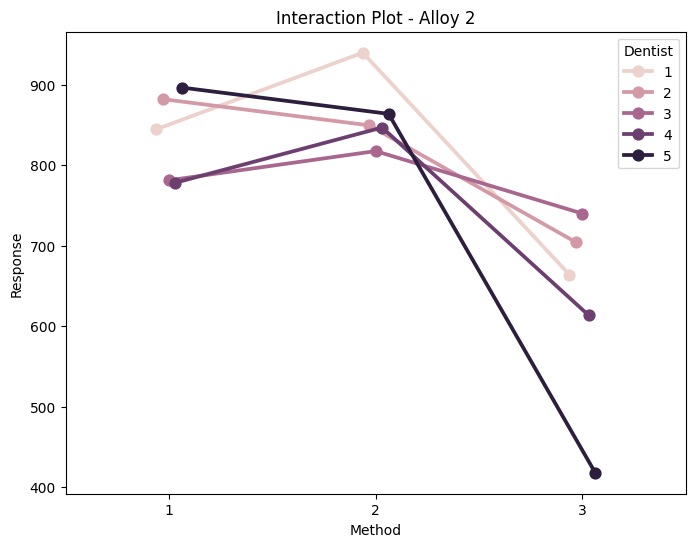

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, levene
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load data
df = pd.read_excel("Dental Hardness data.xlsx", sheet_name="Data")

# Clean column names
df.columns = ["Dentist", "Method", "Alloy", "Temp", "Response"]

# Function to run ANOVA per alloy
def run_anova(alloy_type):
    print(f"\n Alloy Type {alloy_type} Analysis")
    data = df[df["Alloy"] == alloy_type]

    # Model: Dentist + Method + Interaction
    model = ols('Response ~ C(Dentist) + C(Method) + C(Dentist):C(Method)', data=data).fit()

    # Shapiro-Wilk test (normality of residuals)
    shapiro_test = shapiro(model.resid)
    print(f"Shapiro-Wilk p-value: {shapiro_test.pvalue:.4f}")

    # Levene’s test (homogeneity of variances)
    levene_test = levene(*[group["Response"].values for name, group in data.groupby("Dentist")])
    print(f"Levene’s p-value: {levene_test.pvalue:.4f}")

    # ANOVA table
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("\nANOVA Results:\n", anova_table)

    # Post-hoc Tukey HSD (for Dentist effect)
    tukey = pairwise_tukeyhsd(endog=data["Response"],
                              groups=data["Dentist"],
                              alpha=0.05)
    print("\nTukey HSD Results:\n", tukey)

    # Interaction Plot
    plt.figure(figsize=(8,6))
    sns.pointplot(x="Method", y="Response", hue="Dentist", data=data,
                  ci=None, markers="o", dodge=True)
    plt.title(f"Interaction Plot - Alloy {alloy_type}")
    plt.show()

# Run for Alloy 1 and Alloy 2
run_anova(1)
run_anova(2)
